# **Necessary Imports**

In [2]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms.functional as TF
from tqdm.notebook import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr


# **RRDBNet Model Architecture**

In [3]:
class ResidualDenseBlock(nn.Module):
    """Residual Dense Block, used in RRDB."""
    def __init__(self, nf=64, gc=32, bias=True):
        super(ResidualDenseBlock, self).__init__()
        self.conv1 = nn.Conv2d(nf, gc, 3, 1, 1, bias=bias)
        self.conv2 = nn.Conv2d(nf + gc, gc, 3, 1, 1, bias=bias)
        self.conv3 = nn.Conv2d(nf + 2 * gc, gc, 3, 1, 1, bias=bias)
        self.conv4 = nn.Conv2d(nf + 3 * gc, gc, 3, 1, 1, bias=bias)
        self.conv5 = nn.Conv2d(nf + 4 * gc, nf, 3, 1, 1, bias=bias)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        x1 = self.lrelu(self.conv1(x))
        x2 = self.lrelu(self.conv2(torch.cat((x, x1), 1)))
        x3 = self.lrelu(self.conv3(torch.cat((x, x1, x2), 1)))
        x4 = self.lrelu(self.conv4(torch.cat((x, x1, x2, x3), 1)))
        x5 = self.conv5(torch.cat((x, x1, x2, x3, x4), 1))
        return x5 * 0.2 + x

class RRDB(nn.Module):
    """Residual in Residual Dense Block."""
    def __init__(self, nf, gc=32):
        super(RRDB, self).__init__()
        self.RDB1 = ResidualDenseBlock(nf, gc)
        self.RDB2 = ResidualDenseBlock(nf, gc)
        self.RDB3 = ResidualDenseBlock(nf, gc)

    def forward(self, x):
        out = self.RDB1(x)
        out = self.RDB2(out)
        out = self.RDB3(out)
        return out * 0.2 + x

class RRDBNet(nn.Module):
    """The main RRDBNet model for joint denoising and super-resolution."""
    def __init__(self, in_nc, out_nc, nf, nb, gc=32):
        super(RRDBNet, self).__init__()
        self.conv_first = nn.Conv2d(in_nc, nf, 3, 1, 1, bias=True)
        self.rrdb_blocks = nn.ModuleList([RRDB(nf, gc) for _ in range(nb)])
        self.trunk_conv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)

        # The convolution layers before PixelShuffle must produce nf * 4 channels
        self.upconv1 = nn.Conv2d(nf, nf * 4, 3, 1, 1, bias=True)
        self.upconv2 = nn.Conv2d(nf, nf * 4, 3, 1, 1, bias=True)

        self.pixel_shuffle = nn.PixelShuffle(2)
        self.hr_conv = nn.Conv2d(nf, nf, 3, 1, 1, bias=True)
        self.conv_last = nn.Conv2d(nf, out_nc, 3, 1, 1, bias=True)
        self.lrelu = nn.LeakyReLU(negative_slope=0.2, inplace=True)

    def forward(self, x):
        feat = self.conv_first(x)
        trunk = feat
        for block in self.rrdb_blocks:
            trunk = block(trunk)
        trunk = self.trunk_conv(trunk)
        feat = feat + trunk

        # After upconv1, feat has nf*4 channels. After pixel_shuffle, it's back to nf channels.
        feat = self.lrelu(self.pixel_shuffle(self.upconv1(feat)))
        # Same logic for the second upsampling step
        feat = self.lrelu(self.pixel_shuffle(self.upconv2(feat)))

        out = self.conv_last(self.lrelu(self.hr_conv(feat)))
        return out

print("RRDBNet model architecture defined successfully.")

RRDBNet model architecture defined successfully.


# **Dataset Class Definition**

In [4]:
class DenoiseSRDataset(Dataset):
    """Custom Dataset for loading low-res/high-res image pairs."""
    def __init__(self, lr_dir, hr_dir):
        super(DenoiseSRDataset, self).__init__()
        self.lr_dir = lr_dir
        self.hr_dir = hr_dir
        self.lr_image_files = sorted([f for f in os.listdir(lr_dir) if f.endswith(('.png', '.jpg'))])
        self.hr_image_files = sorted([f for f in os.listdir(hr_dir) if f.endswith(('.png', '.jpg'))])
        assert len(self.lr_image_files) == len(self.hr_image_files), "Mismatch in number of LR and HR images"

    def __len__(self):
        return len(self.lr_image_files)

    def __getitem__(self, idx):
        lr_img_path = os.path.join(self.lr_dir, self.lr_image_files[idx])
        hr_img_path = os.path.join(self.hr_dir, self.hr_image_files[idx])
        lr_image = Image.open(lr_img_path).convert('RGB')
        hr_image = Image.open(hr_img_path).convert('RGB')
        lr_tensor = TF.to_tensor(lr_image)
        hr_tensor = TF.to_tensor(hr_image)
        return {'lr': lr_tensor, 'hr': hr_tensor}

print("Dataset class defined successfully.")

Dataset class defined successfully.


# **Dataset loading**

In [5]:
DATA_DIR = '/kaggle/input/dlp-may-2025-nppe-3/archive'

TRAIN_LR_DIR = os.path.join(DATA_DIR, 'train/train')
TRAIN_HR_DIR = os.path.join(DATA_DIR, 'train/gt')
VAL_LR_DIR = os.path.join(DATA_DIR, 'val/val')
VAL_HR_DIR = os.path.join(DATA_DIR, 'val/gt')
TEST_LR_DIR = os.path.join(DATA_DIR, 'test/')

KAGGLE_WORKING_DIR = '/kaggle/working/'
OUTPUT_DIR = os.path.join(KAGGLE_WORKING_DIR, 'submission_images/')
MODEL_SAVE_PATH = os.path.join(KAGGLE_WORKING_DIR, 'best_model.pth')
SUBMISSION_CSV_PATH = os.path.join(KAGGLE_WORKING_DIR, '21F3002062.csv')
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 4
NUM_EPOCHS = 40
LEARNING_RATE = 1e-4
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

print(f"Using device: {DEVICE}")
print(f"Number of available GPUs: {torch.cuda.device_count()}")

Using device: cuda
Number of available GPUs: 2


# **Training the model**

In [6]:
train_dataset = DenoiseSRDataset(lr_dir=TRAIN_LR_DIR, hr_dir=TRAIN_HR_DIR)
val_dataset = DenoiseSRDataset(lr_dir=VAL_LR_DIR, hr_dir=VAL_HR_DIR)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=2)

# --- Model Instantiation with DataParallel for Multi-GPU ---

model = RRDBNet(in_nc=3, out_nc=3, nf=64, nb=12)
if torch.cuda.device_count() > 1:
  print(f"Using {torch.cuda.device_count()} GPUs!")
  model = nn.DataParallel(model)
model.to(DEVICE)

criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=40, eta_min=1e-6)

Using 2 GPUs!


In [7]:
best_psnr = 0.0
for epoch in range(NUM_EPOCHS):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Training]")
    for batch in pbar:
        lr_images = batch['lr'].to(DEVICE)
        hr_images = batch['hr'].to(DEVICE)
        optimizer.zero_grad()
        sr_images = model(lr_images)
        loss = criterion(sr_images, hr_images)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.6f}'})

    avg_train_loss = running_loss / len(train_loader)

    
    model.eval()
    val_psnr = 0.0
    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [Validation]"):
            lr_images = batch['lr'].to(DEVICE)
            hr_images = batch['hr'].to(DEVICE)
            sr_images = model(lr_images).clamp(0.0, 1.0)
            hr_numpy = hr_images.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            sr_numpy = sr_images.squeeze(0).cpu().numpy().transpose(1, 2, 0)
            val_psnr += psnr(hr_numpy, sr_numpy, data_range=1.0)

    avg_val_psnr = val_psnr / len(val_loader)
    print(f"Epoch {epoch+1}, Train Loss: {avg_train_loss:.6f}, Val PSNR: {avg_val_psnr:.4f}")

    if avg_val_psnr > best_psnr:
        best_psnr = avg_val_psnr
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"New best model saved with PSNR: {best_psnr:.4f}")

    scheduler.step()

print("Training finished.")

Epoch 1/40 [Training]:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 1/40 [Validation]:   0%|          | 0/267 [00:00<?, ?it/s]

Epoch 1, Train Loss: 0.018933, Val PSNR: 35.6494
New best model saved with PSNR: 35.6494


Epoch 2/40 [Training]:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 2/40 [Validation]:   0%|          | 0/267 [00:00<?, ?it/s]

...

Epoch 39/40 [Validation]:   0%|          | 0/267 [00:00<?, ?it/s]

Epoch 39, Train Loss: 0.009398, Val PSNR: 38.9628


Epoch 40/40 [Training]:   0%|          | 0/277 [00:00<?, ?it/s]

Epoch 40/40 [Validation]:   0%|          | 0/267 [00:00<?, ?it/s]

Epoch 40, Train Loss: 0.009388, Val PSNR: 38.9721
Training finished.


# **Inference on the Test Set**

In [8]:
print(f"Loading best model from {MODEL_SAVE_PATH}")

inference_model = RRDBNet(in_nc=3, out_nc=3, nf=64, nb=12)
if torch.cuda.device_count() > 1:
  inference_model = nn.DataParallel(inference_model)
inference_model.to(DEVICE)
inference_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
inference_model.eval()

# --- Process Test Images ---
print(f"Processing test images from {TEST_LR_DIR}...")
test_files = sorted([f for f in os.listdir(TEST_LR_DIR) if f.endswith(('.png', '.jpg'))])

with torch.no_grad():
    for filename in tqdm(test_files, desc="Generating submission images"):
        img_path = os.path.join(TEST_LR_DIR, filename)
        lr_image = Image.open(img_path).convert('RGB')
        lr_tensor = TF.to_tensor(lr_image).unsqueeze(0).to(DEVICE)
        sr_tensor = inference_model(lr_tensor).clamp(0.0, 1.0)
        sr_image_numpy = sr_tensor.squeeze(0).cpu().numpy().transpose(1, 2, 0)
        sr_image_uint8 = (sr_image_numpy * 255.0).round().astype(np.uint8)
        pil_img = Image.fromarray(sr_image_uint8)
        pil_img.save(os.path.join(OUTPUT_DIR, filename))

print(f"Inference complete. Enhanced images saved to '{OUTPUT_DIR}'.")

Loading best model from /kaggle/working/best_model.pth
Processing test images from /kaggle/input/dlp-may-2025-nppe-3/archive/test/...


Generating submission images:   0%|          | 0/60 [00:00<?, ?it/s]

Inference complete. Enhanced images saved to '/kaggle/working/submission_images/'.


# **Create Submission File**

In [9]:
def images_to_csv(folder_path, output_csv):
    data_rows = []
    filenames = sorted(os.listdir(folder_path))

    for filename in tqdm(filenames, desc="Creating Submission File"):
        if filename.lower().endswith(('.png', '.jpg', '.jpeg')):
            image_path = os.path.join(folder_path, filename)
            image = Image.open(image_path).convert('L') # Convert to Grayscale
            # Flatten and subsample every 8th pixel as per specific instructions
            image_array = np.array(image).flatten()[::8]
            image_id = filename.split('.')[0].replace('test_', 'gt_')
            data_rows.append([image_id, *image_array])

    if not data_rows:
        print("Warning: No images found in the prediction folder.")
        return

    num_pixels = len(data_rows[0]) - 1
    column_names = ['ID'] + [f'pixel_{i}' for i in range(num_pixels)]
    df = pd.DataFrame(data_rows, columns=column_names)
    df.to_csv(output_csv, index=False)
    print(f'Successfully saved submission file to {output_csv}')

images_to_csv(folder_path=OUTPUT_DIR, output_csv=SUBMISSION_CSV_PATH)

print("\nNotebook execution complete!")


Creating Submission File:   0%|          | 0/60 [00:00<?, ?it/s]

Successfully saved submission file to /kaggle/working/21F3002062.csv

Notebook execution complete!


# **Visualizing some Enhanced predicted images**

Displaying 5 image comparisons...


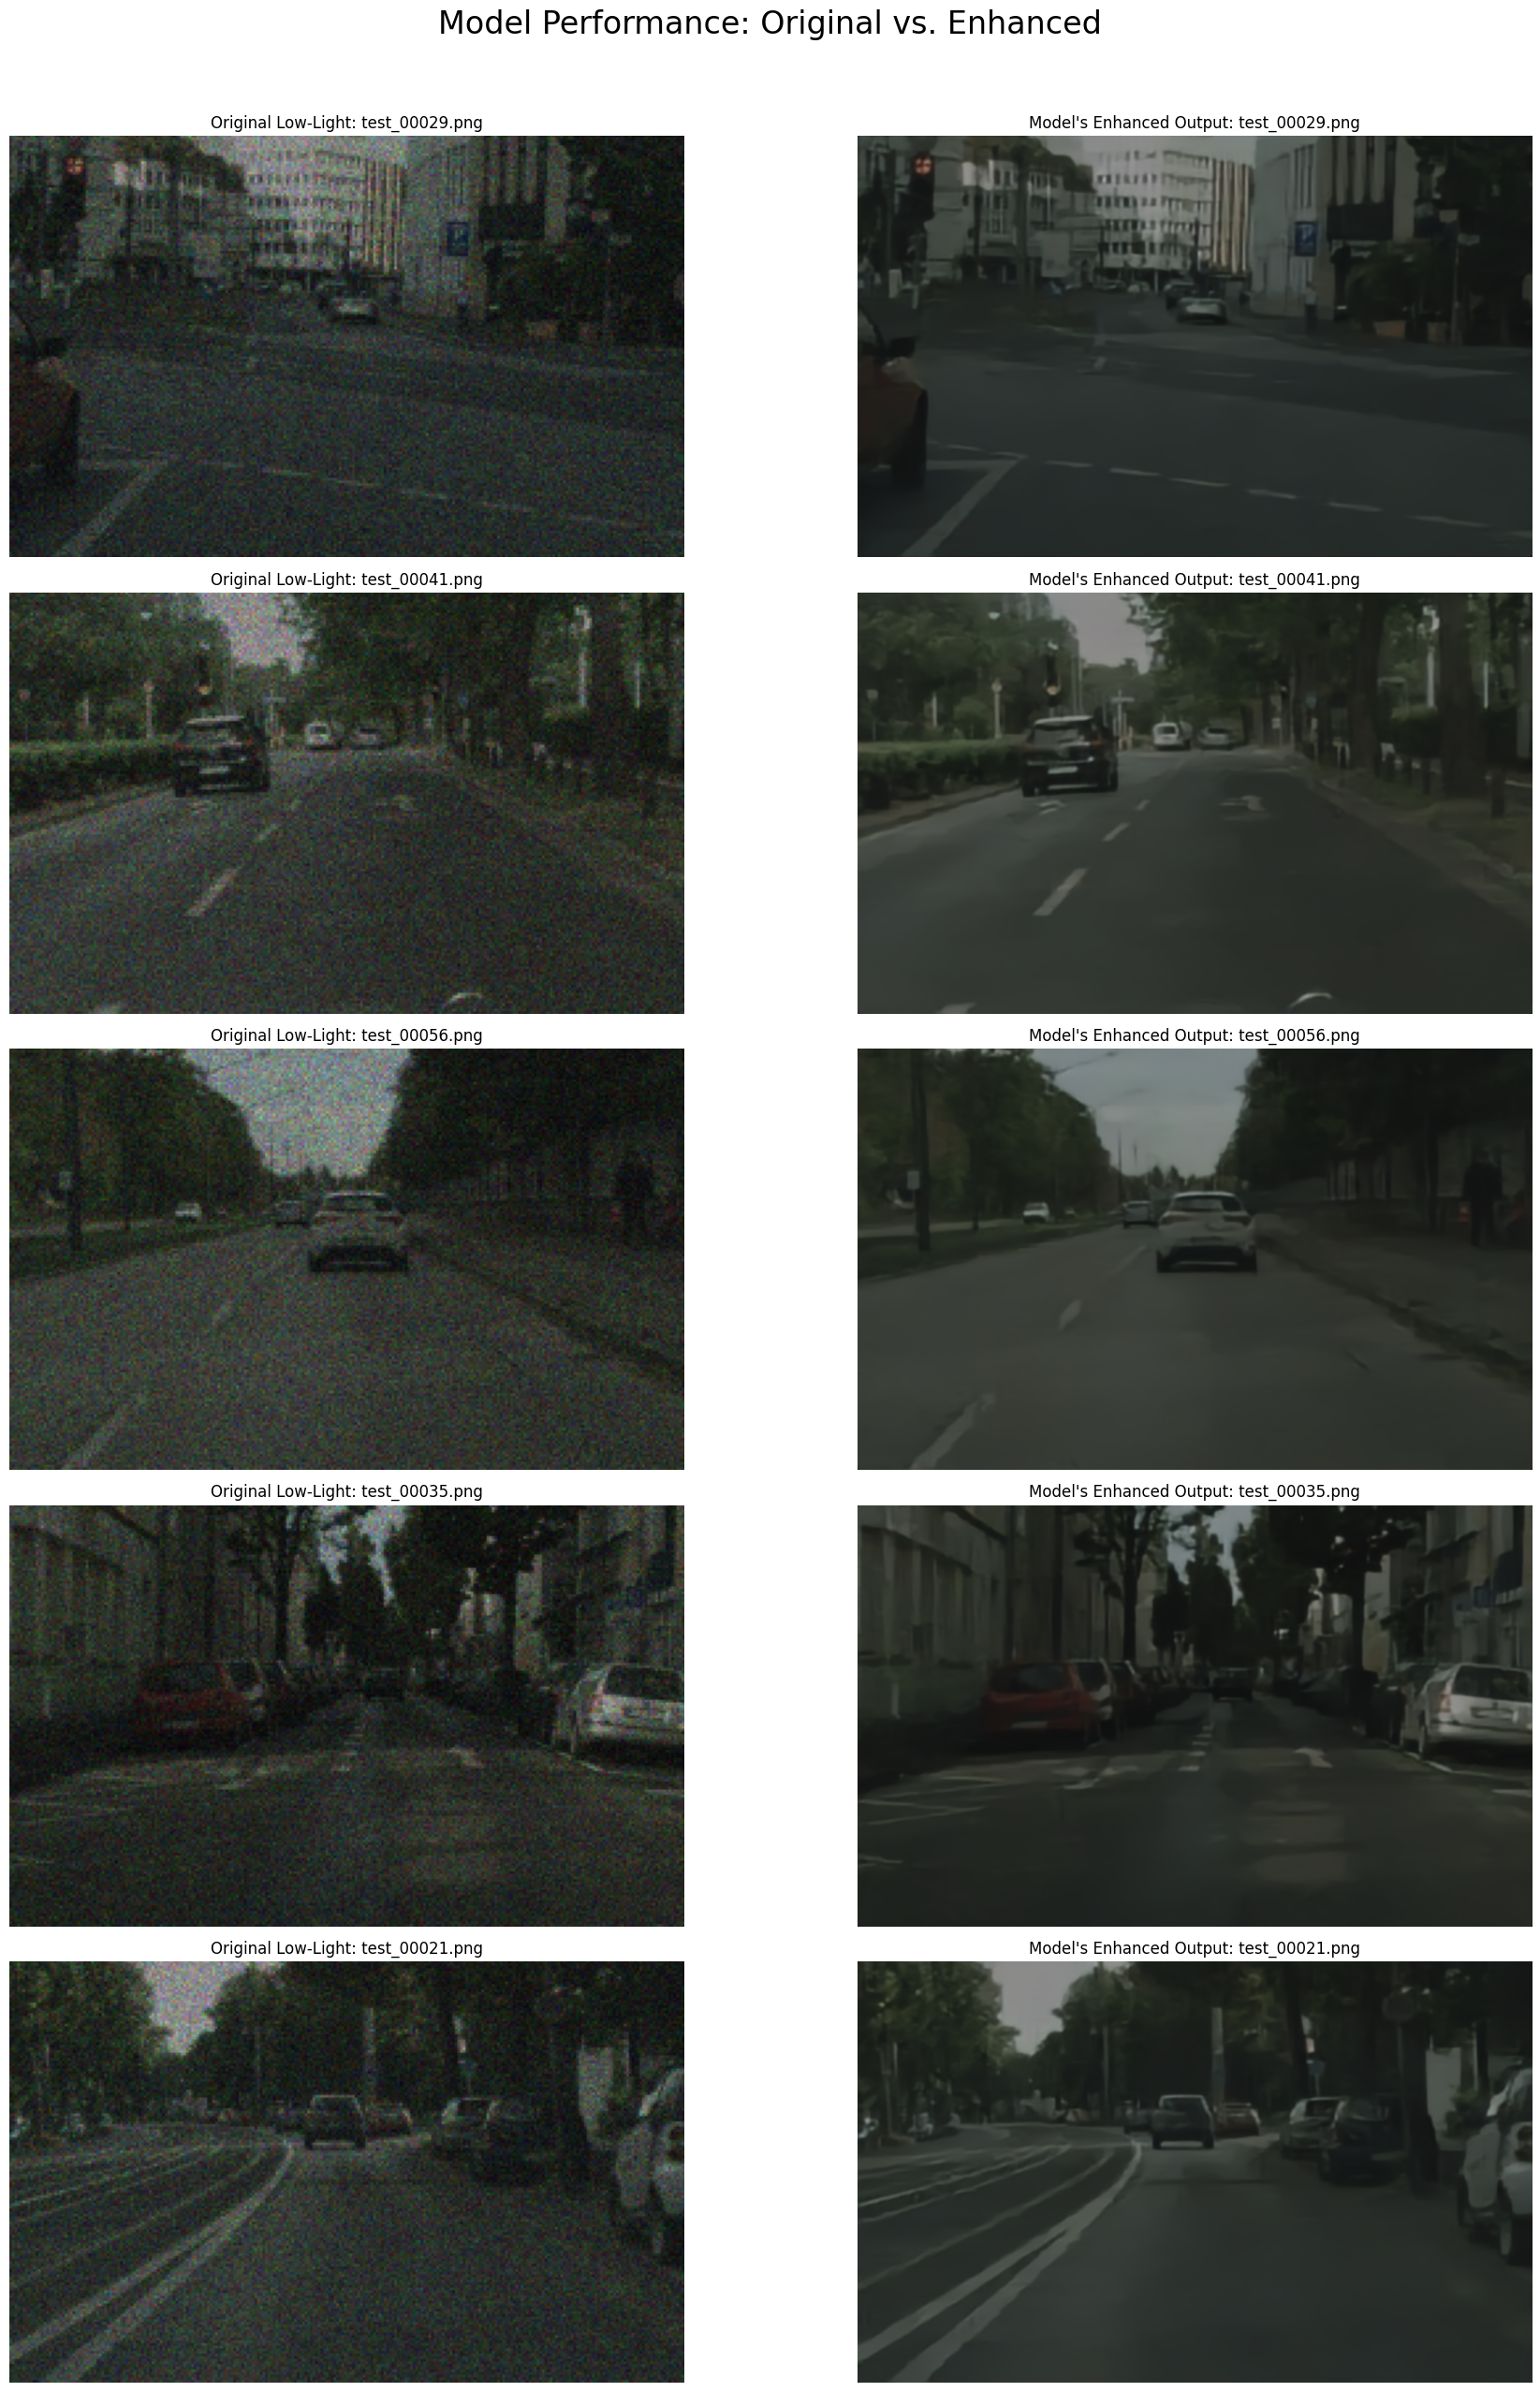

In [10]:
import matplotlib.pyplot as plt
import random
from PIL import Image

num_images_to_show = 5

# --- Get a list of original and predicted images ---
original_image_files = sorted(os.listdir(TEST_LR_DIR))
predicted_image_files = sorted(os.listdir(OUTPUT_DIR))

# --- Randomly select some images to display ---
if len(original_image_files) > num_images_to_show:
    # Get random indices to display a variety of images each time
    selected_indices = random.sample(range(len(original_image_files)), num_images_to_show)
else:
    # If there are fewer images than we want to show, just show them all
    selected_indices = range(len(original_image_files))

print(f"Displaying {len(selected_indices)} image comparisons...")

# --- Create the plots ---
# Set up a figure to hold all the comparison plots
plt.figure(figsize=(20, 5 * num_images_to_show))
plt.suptitle('Model Performance: Original vs. Enhanced', fontsize=24, y=1.02)

for i, index in enumerate(selected_indices):
    # Get the filename
    filename = original_image_files[index]
    
    # Load the original low-light image
    original_path = os.path.join(TEST_LR_DIR, filename)
    original_image = Image.open(original_path)
    
    # Load your model's enhanced high-resolution image
    predicted_path = os.path.join(OUTPUT_DIR, filename)
    predicted_image = Image.open(predicted_path)

    # --- Plot the Original Image ---
    ax = plt.subplot(num_images_to_show, 2, 2 * i + 1)
    ax.imshow(original_image)
    ax.set_title(f"Original Low-Light: {filename}")
    ax.axis('off') # Hide the axes ticks

    # --- Plot the Enhanced Image ---
    ax = plt.subplot(num_images_to_show, 2, 2 * i + 2)
    ax.imshow(predicted_image)
    ax.set_title(f"Model's Enhanced Output: {filename}")
    ax.axis('off') # Hide the axes ticks

plt.tight_layout()
plt.show()